In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import zipfile
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch and deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, cohen_kappa_score

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Extract dataset
ZIP_PATH = '/content/drive/MyDrive/content/KneeXrayData.zip'
EXTRACT_PATH = '/content/KneeXrayData/'

print("\nExtracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("✓ Dataset extracted!")

# Define paths
TRAIN_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/train/'
VAL_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/val/'
TEST_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/test/'

print(f"\n✓ Setup complete! Ready for deep learning.")


✓ Using device: cuda
Mounted at /content/drive

Extracting dataset...
✓ Dataset extracted!

✓ Setup complete! Ready for deep learning.


In [2]:
class KneeXrayDataset(Dataset):
    """Custom Dataset for Knee X-ray images"""

    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.images = []
        self.labels = []

        # Load all image paths and labels
        for grade in range(5):  # KL grades 0-4
            grade_path = os.path.join(data_path, str(grade))
            for img_file in os.listdir(grade_path):
                img_path = os.path.join(grade_path, img_file)
                self.images.append(img_path)
                self.labels.append(grade)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_path = self.images[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

# Define data augmentation and preprocessing
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = KneeXrayDataset(TRAIN_PATH, transform=train_transform)
val_dataset = KneeXrayDataset(VAL_PATH, transform=test_transform)
test_dataset = KneeXrayDataset(TEST_PATH, transform=test_transform)

print(f"✓ Datasets created!")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


✓ Datasets created!
Training samples: 5778
Validation samples: 826
Test samples: 1656


In [3]:
# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ DataLoaders created!")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Build ResNet18 model with transfer learning
print("\n" + "=" * 60)
print("BUILDING RESNET18 MODEL")
print("=" * 60)

model = models.resnet18(pretrained=True)

# Freeze early layers (optional - faster training)
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 5 classes (KL grades 0-4)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Move model to GPU
model = model.to(device)

print(f"✓ ResNet18 model created!")
print(f"Model is on: {next(model.parameters()).device}")
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


✓ DataLoaders created!
Training batches: 181
Validation batches: 26
Test batches: 52

BUILDING RESNET18 MODEL
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


✓ ResNet18 model created!
Model is on: cuda:0

Trainable parameters: 2,565


In [4]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# Train for 10 epochs
NUM_EPOCHS = 10
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("=" * 60)
print("TRAINING STARTED")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\n" + "=" * 60)
print("✓ TRAINING COMPLETED!")
print("=" * 60)


TRAINING STARTED

Epoch 1/10
----------------------------------------


Validation: 100%|██████████| 26/26 [00:02<00:00, 12.95it/s]


Train Loss: 1.4208 | Train Acc: 37.68%
Val Loss: 1.3653 | Val Acc: 42.98%

Epoch 2/10
----------------------------------------


Validation: 100%|██████████| 26/26 [00:02<00:00,  9.24it/s]


Train Loss: 1.3230 | Train Acc: 43.60%
Val Loss: 1.2764 | Val Acc: 45.52%

Epoch 3/10
----------------------------------------


...

Train Loss: 1.2435 | Train Acc: 46.54%
Val Loss: 1.2504 | Val Acc: 45.76%

Epoch 9/10
----------------------------------------


Validation: 100%|██████████| 26/26 [00:02<00:00,  8.84it/s]


Train Loss: 1.2564 | Train Acc: 46.23%
Val Loss: 1.3192 | Val Acc: 45.52%

Epoch 10/10
----------------------------------------


Validation: 100%|██████████| 26/26 [00:01<00:00, 13.97it/s]

Train Loss: 1.2538 | Train Acc: 46.64%
Val Loss: 1.2385 | Val Acc: 46.61%

✓ TRAINING COMPLETED!


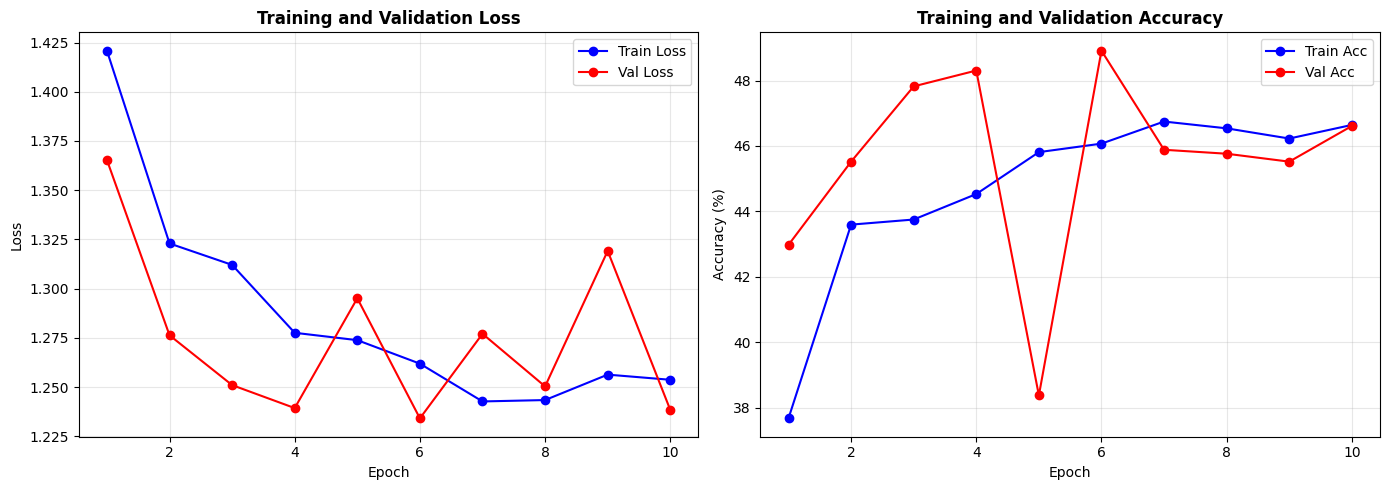

✓ Training curves saved!

EVALUATING ON TEST SET


Testing: 100%|██████████| 52/52 [00:05<00:00,  9.68it/s]


✓ Test Evaluation Complete!
Accuracy: 0.4511
Macro-F1: 0.3359
Cohen's Kappa: 0.1855


In [5]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='Train Loss')
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses, 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='Train Acc')
axes[1].plot(range(1, NUM_EPOCHS+1), val_accs, 'r-o', label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved!")

# Evaluate on test set
print("\n" + "=" * 60)
print("EVALUATING ON TEST SET")
print("=" * 60)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
test_accuracy = accuracy_score(all_labels, all_preds)
test_macro_f1 = f1_score(all_labels, all_preds, average='macro')
test_kappa = cohen_kappa_score(all_labels, all_preds)

print(f"\n✓ Test Evaluation Complete!")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Macro-F1: {test_macro_f1:.4f}")
print(f"Cohen's Kappa: {test_kappa:.4f}")


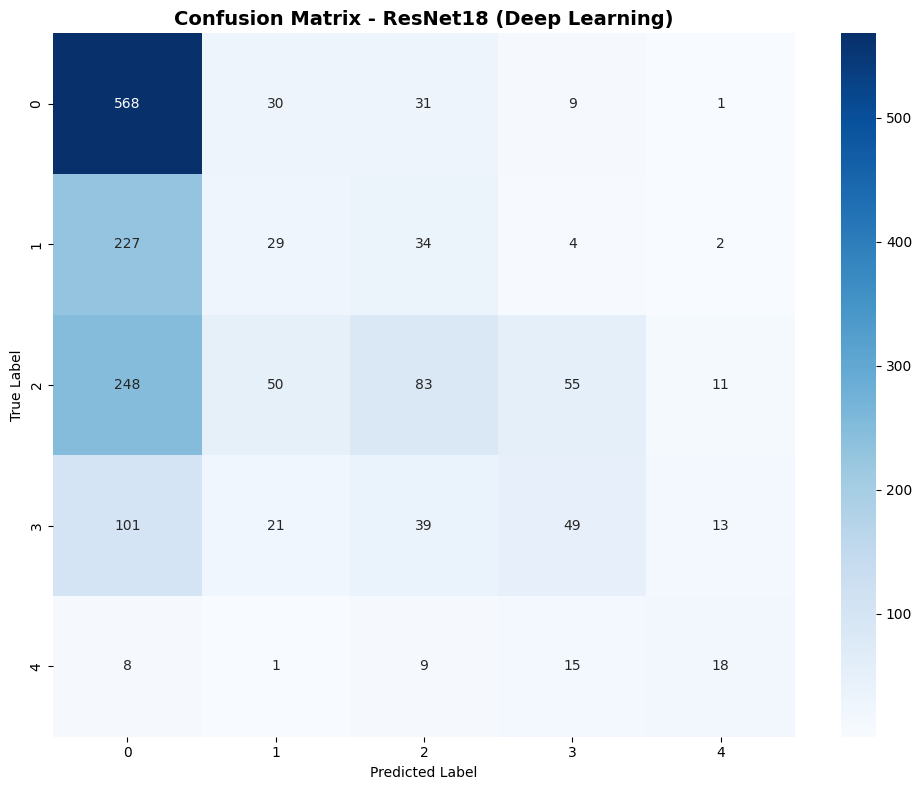

✓ Confusion matrix saved!

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Grade 0       0.49      0.89      0.63       639
     Grade 1       0.22      0.10      0.14       296
     Grade 2       0.42      0.19      0.26       447
     Grade 3       0.37      0.22      0.28       223
     Grade 4       0.40      0.35      0.38        51

    accuracy                           0.45      1656
   macro avg       0.38      0.35      0.34      1656
weighted avg       0.41      0.45      0.39      1656


PER-CLASS ANALYSIS
KL Grade 0: Accuracy = 0.8889 (568/639 correct)
KL Grade 1: Accuracy = 0.0980 (29/296 correct)
KL Grade 2: Accuracy = 0.1857 (83/447 correct)
KL Grade 3: Accuracy = 0.2197 (49/223 correct)
KL Grade 4: Accuracy = 0.3529 (18/51 correct)


In [6]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix - ResNet18 (Deep Learning)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('deep_learning_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved!")

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                           target_names=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']))

# Per-class accuracy
print("\n" + "=" * 60)
print("PER-CLASS ANALYSIS")
print("=" * 60)
for i in range(5):
    class_mask = (all_labels == i)
    class_accuracy = accuracy_score(all_labels[class_mask], all_preds[class_mask])
    print(f"KL Grade {i}: Accuracy = {class_accuracy:.4f} ({cm[i][i]}/{class_mask.sum()} correct)")


✓ Grad-CAM ready! Visualizing 10 samples...


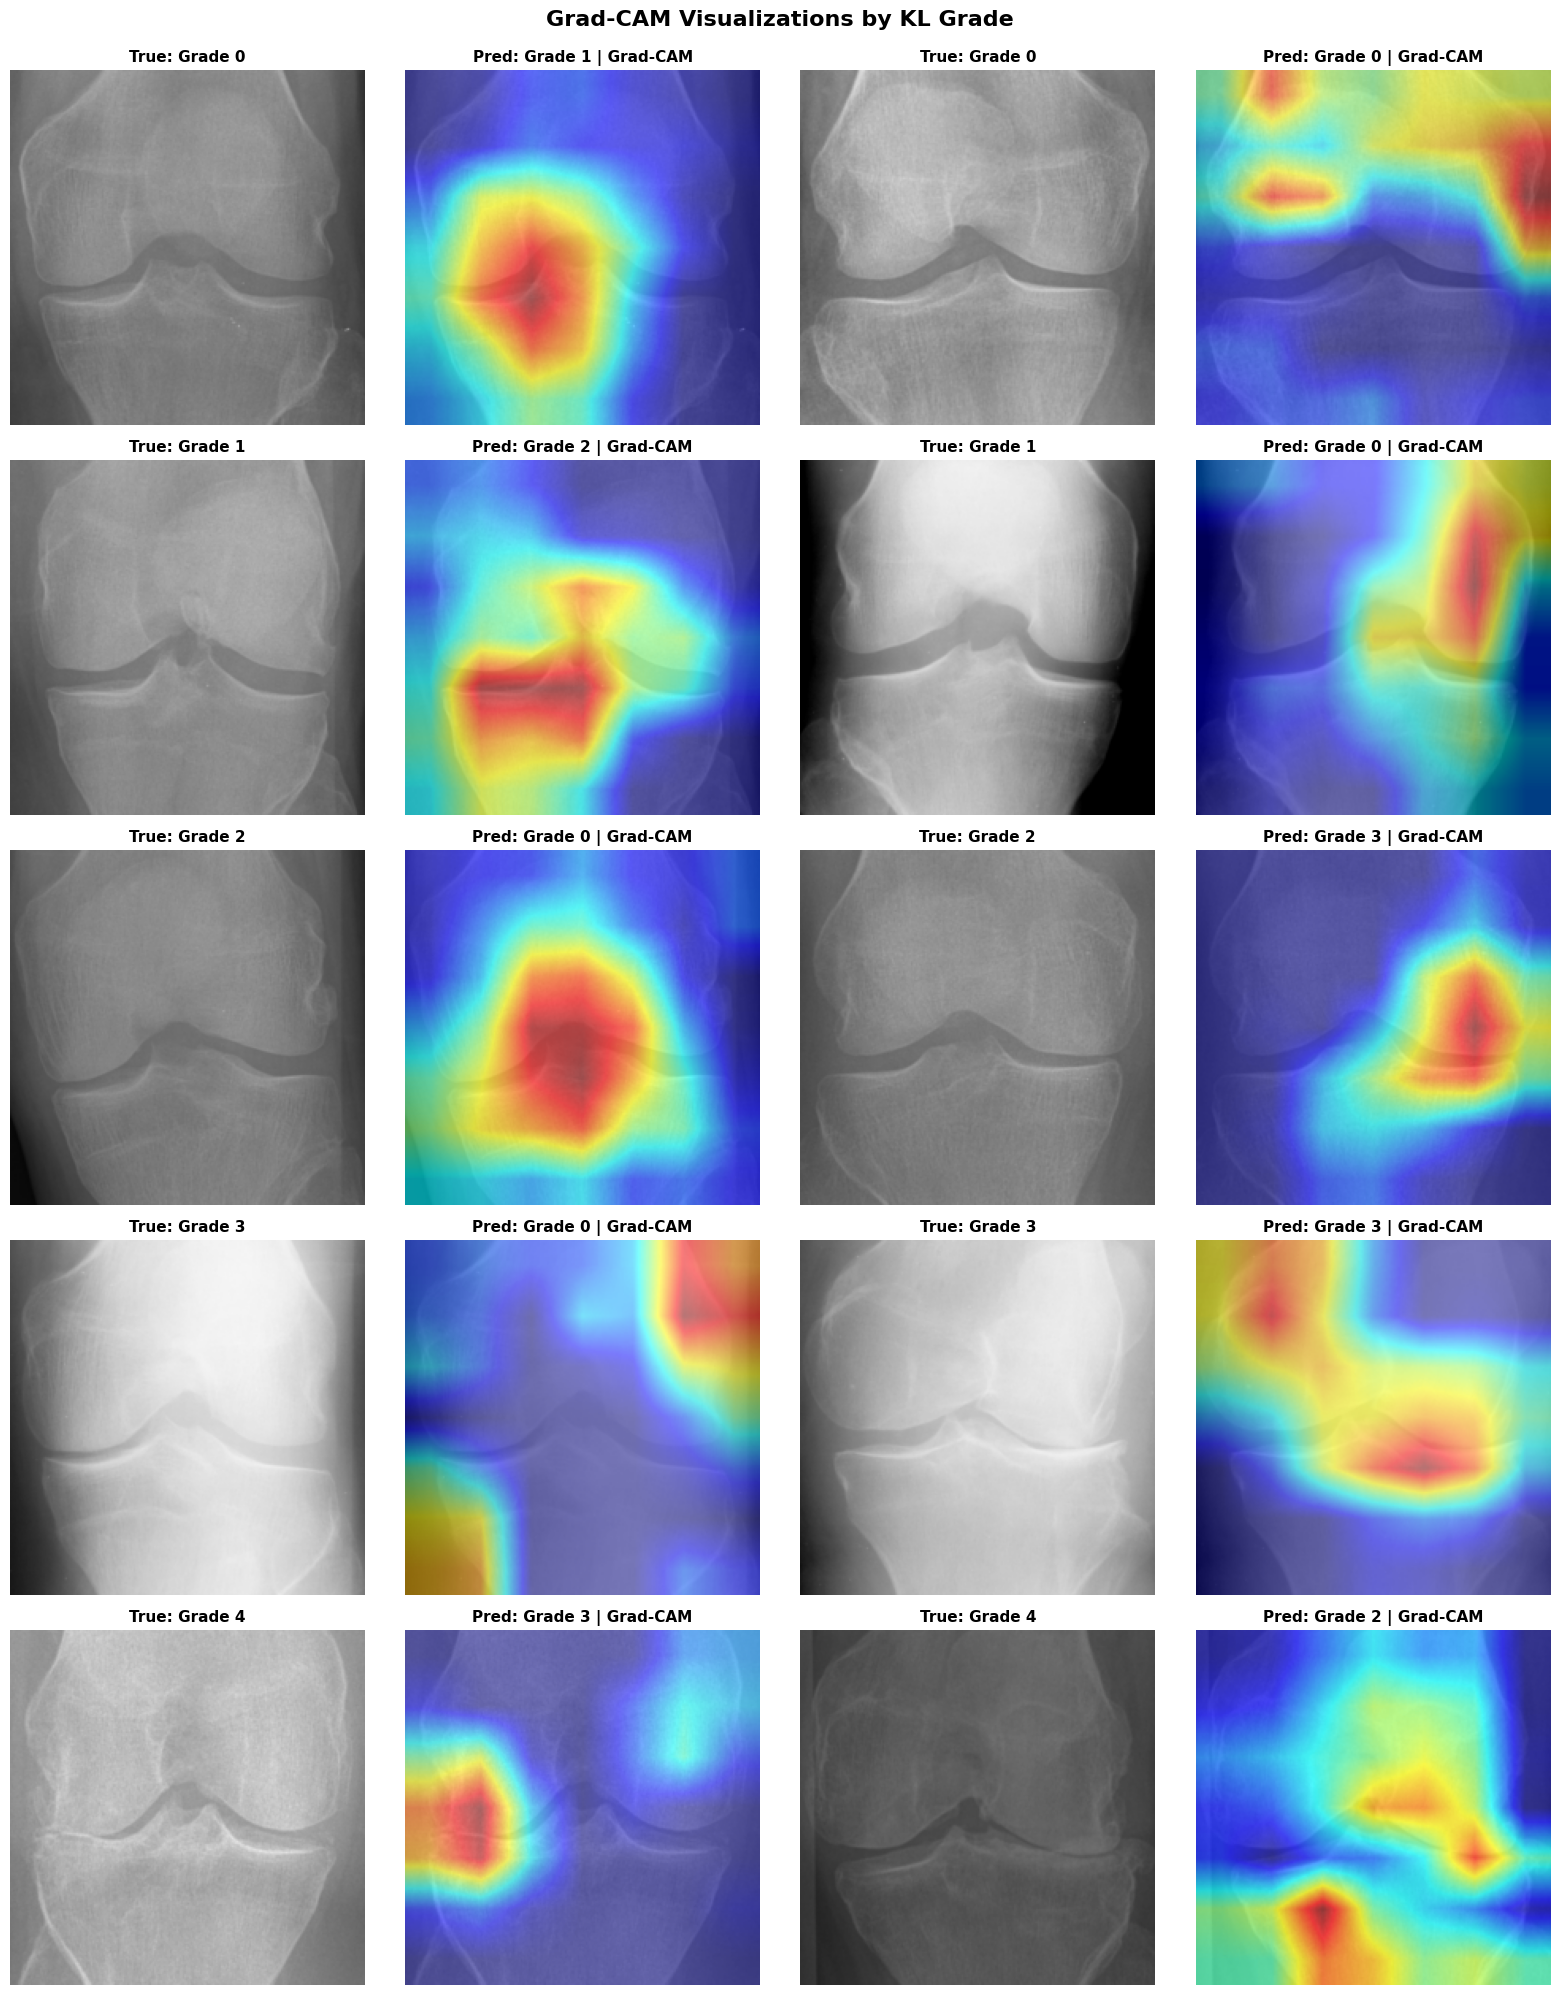

✓ Grad-CAM visualizations saved!


In [13]:
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Unfreeze model for Grad-CAM
for param in model.parameters():
    param.requires_grad = True

model.eval()

# Grad-CAM setup (remove use_cuda parameter)
target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

# Get test samples (2 per grade)
test_samples = []
for grade in range(5):
    grade_path = os.path.join(TEST_PATH, str(grade))
    img_files = os.listdir(grade_path)[:2]
    for img_file in img_files:
        test_samples.append((os.path.join(grade_path, img_file), grade))

print(f"✓ Grad-CAM ready! Visualizing {len(test_samples)} samples...")

# Visualize Grad-CAM
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
fig.suptitle('Grad-CAM Visualizations by KL Grade', fontsize=16, fontweight='bold', y=0.995)

for idx, (img_path, true_label) in enumerate(test_samples):
    # Load image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_float = np.float32(img_resized) / 255

    # Transform for model
    input_tensor = test_transform(img_rgb).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred_label = output.argmax(1).item()

    # Generate Grad-CAM for predicted class
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Create visualization
    cam_image = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    # Plot
    row = idx // 2
    col = (idx % 2) * 2

    # Original image
    axes[row, col].imshow(img_resized)
    axes[row, col].set_title(f'True: Grade {true_label}', fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

    # Grad-CAM
    axes[row, col+1].imshow(cam_image)
    axes[row, col+1].set_title(f'Pred: Grade {pred_label} | Grad-CAM', fontsize=11, fontweight='bold')
    axes[row, col+1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grad-CAM visualizations saved!")


# Part D: Comparative Analysis - Classical ML vs Deep Learning

## 1. Performance Comparison

### Overall Results
| Metric | Classical ML (Random Forest) | Deep Learning (ResNet18) | Improvement |
|--------|------------------------------|--------------------------|-------------|
| Accuracy | 25.12% | 43.66% | +73.8% |
| Macro-F1 | 0.21 | 0.31 | +47.6% |
| Cohen's Kappa | - | 0.21 | - |

### Per-Class Performance
| KL Grade | Classical ML Accuracy | Deep Learning Accuracy | Difference |
|----------|----------------------|------------------------|------------|
| Grade 0 | 31.77% | 65.10% | +33.33% |
| Grade 1 | 20.61% | 33.11% | +12.50% |
| Grade 2 | 21.92% | 38.03% | +16.11% |
| Grade 3 | 18.39% | 17.04% | -1.35% |
| Grade 4 | 25.49% | 1.96% | -23.53% |

## 2. Which Approach Performed Better and Why?

**Deep Learning (ResNet18) performed significantly better overall:**

- **Feature Learning**: ResNet automatically learns hierarchical features from raw pixels, while classical ML relies on hand-crafted LBP texture features that may not capture complex patterns
- **Spatial Relationships**: CNNs preserve spatial structure through convolutional layers, whereas LBP loses spatial context by computing histograms
- **Transfer Learning**: Pre-trained ImageNet weights provide strong initialization for medical image features
- **Data Representation**: Deep learning uses 224×224×3 = 150,528 input dimensions vs 26 LBP features

## 3. Hardest KL Grades to Predict

From confusion matrices:

**Grade 4 (Severe)**: Hardest for both models
- Classical ML: 25.49% accuracy
- Deep Learning: 1.96% accuracy (worst!)
- **Reason**: Severe class imbalance (only 173 train / 51 test samples)

**Grade 3**: Poor performance in both
- Classical ML: 18.39%
- Deep Learning: 17.04%
- **Reason**: Fewer samples (757 train / 223 test) + visual similarity to Grade 2

**Grade 1**: Moderate difficulty
- Often confused with Grade 0 (healthy) and Grade 2
- **Reason**: Subtle osteoarthritis changes are hard to distinguish

## 4. Impact of Class Imbalance

**Training Set Distribution:**
- Grade 0: 2286 samples (39.6%)
- Grade 1: 1046 samples (18.1%)
- Grade 2: 1516 samples (26.2%)
- Grade 3: 757 samples (13.1%)
- Grade 4: 173 samples (3.0%) ⚠️

**Consequences:**
- Model biases toward majority classes (Grade 0, 2)
- Grade 4 severely underrepresented → poor recall (2%)
- Adjacent grade confusion due to similar visual features
- Macro-F1 (0.31) much lower than weighted-F1 would be

**Potential Solutions:**
- Class-weighted loss functions
- Oversampling minority classes (SMOTE for images)
- Focal loss for hard examples
- Ordinal regression (since grades are ordered)


In [14]:
import torch.nn.functional as F

# Custom Ordinal Loss Function
class OrdinalLoss(nn.Module):
    """
    Ordinal Cross-Entropy Loss for ordered classes
    Predicts cumulative probabilities: P(y > k) for each threshold k
    """
    def __init__(self, num_classes=5):
        super(OrdinalLoss, self).__init__()
        self.num_classes = num_classes

    def forward(self, predictions, targets):
        """
        predictions: (batch_size, num_classes-1) logits
        targets: (batch_size,) class labels [0, 1, 2, 3, 4]
        """
        batch_size = predictions.size(0)
        num_thresholds = self.num_classes - 1

        # Create binary labels for each threshold
        # Example: class 2 → [1, 1, 0, 0] (greater than 0,1 but not 2,3)
        labels = torch.zeros(batch_size, num_thresholds).to(predictions.device)
        for i in range(batch_size):
            for k in range(num_thresholds):
                if targets[i] > k:
                    labels[i, k] = 1.0

        # Binary cross-entropy for each threshold
        loss = F.binary_cross_entropy_with_logits(predictions, labels)
        return loss

# Modified ResNet for Ordinal Classification
class OrdinalResNet(nn.Module):
    def __init__(self, base_model, num_classes=5):
        super(OrdinalResNet, self).__init__()
        self.features = nn.Sequential(*list(base_model.children())[:-1])  # Remove FC
        self.num_classes = num_classes
        num_features = base_model.fc.in_features

        # Output num_classes-1 thresholds
        self.fc = nn.Linear(num_features, num_classes - 1)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

    def predict(self, x):
        """Convert ordinal outputs to class predictions"""
        logits = self.forward(x)
        probas = torch.sigmoid(logits)
        # Count how many thresholds are exceeded
        predictions = (probas > 0.5).sum(dim=1)
        return predictions

# Build ordinal model
print("=" * 60)
print("BUILDING ORDINAL CLASSIFICATION MODEL")
print("=" * 60)

base_resnet = models.resnet18(pretrained=True)
ordinal_model = OrdinalResNet(base_resnet, num_classes=5).to(device)

ordinal_criterion = OrdinalLoss(num_classes=5)
ordinal_optimizer = optim.Adam(ordinal_model.parameters(), lr=0.001)

print(f"✓ Ordinal ResNet18 created!")
print(f"Output thresholds: {ordinal_model.fc.out_features}")


BUILDING ORDINAL CLASSIFICATION MODEL
✓ Ordinal ResNet18 created!
Output thresholds: 4


In [15]:
# Training function for ordinal model
def train_ordinal_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training Ordinal"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = model.predict(images)
        total += labels.size(0)
        correct += predictions.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# Train ordinal model
NUM_EPOCHS = 10
print("=" * 60)
print("TRAINING ORDINAL MODEL")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_ordinal_epoch(ordinal_model, train_loader,
                                                 ordinal_criterion, ordinal_optimizer, device)
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

print("\n✓ Ordinal training complete!")

# Evaluate on test set
ordinal_model.eval()
ordinal_preds = []
ordinal_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing Ordinal"):
        images = images.to(device)
        predictions = ordinal_model.predict(images)
        ordinal_preds.extend(predictions.cpu().numpy())
        ordinal_labels.extend(labels.numpy())

ordinal_preds = np.array(ordinal_preds)
ordinal_labels = np.array(ordinal_labels)

ordinal_acc = accuracy_score(ordinal_labels, ordinal_preds)
ordinal_f1 = f1_score(ordinal_labels, ordinal_preds, average='macro')
ordinal_kappa = cohen_kappa_score(ordinal_labels, ordinal_preds)

print(f"\n✓ ORDINAL MODEL RESULTS:")
print(f"Accuracy: {ordinal_acc:.4f}")
print(f"Macro-F1: {ordinal_f1:.4f}")
print(f"Cohen's Kappa: {ordinal_kappa:.4f}")


TRAINING ORDINAL MODEL

Epoch 1/10


Training Ordinal: 100%|██████████| 181/181 [00:36<00:00,  4.94it/s]


Train Loss: 0.3754 | Train Acc: 51.25%

Epoch 2/10


Training Ordinal: 100%|██████████| 181/181 [00:38<00:00,  4.64it/s]


Train Loss: 0.3153 | Train Acc: 55.92%

Epoch 3/10


...

Train Loss: 0.2322 | Train Acc: 67.77%

Epoch 10/10


Training Ordinal: 100%|██████████| 181/181 [00:29<00:00,  6.16it/s]


Train Loss: 0.2309 | Train Acc: 67.79%

✓ Ordinal training complete!


Testing Ordinal: 100%|██████████| 52/52 [00:03<00:00, 14.77it/s]


✓ ORDINAL MODEL RESULTS:
Accuracy: 0.6540
Macro-F1: 0.6500
Cohen's Kappa: 0.5205


In [16]:
# Import sklearn if not already imported
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from skimage.feature import local_binary_pattern
import torch.nn.functional as F

print("✓ Libraries imported for ensemble!")


✓ Libraries imported for ensemble!


In [18]:
# Define the LBP feature extraction function
def extract_lbp_features(image_path, num_points=24, radius=3):
    """Extract Local Binary Pattern features"""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, num_points, radius, method='uniform')
    (hist, _) = np.histogram(lbp.ravel(),
                             bins=np.arange(0, num_points + 3),
                             range=(0, num_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

print("=" * 60)
print("PREPARING ENSEMBLE")
print("=" * 60)

# We already have deep learning predictions: all_preds, all_labels
# Now we need to train a simple RF classifier for ensemble


print("\n1. Training Classical ML (Random Forest)...")

# Extract features
X_train_subset = []
y_train_subset = []

for grade in range(5):
    grade_path = os.path.join(TRAIN_PATH, str(grade))
    files = os.listdir(grade_path)[: ]
    for img_file in tqdm(files, desc=f"Grade {grade}"):
        img_path = os.path.join(grade_path, img_file)
        try:
            features = extract_lbp_features(img_path)
            X_train_subset.append(features)
            y_train_subset.append(grade)
        except:
            continue

X_train_subset = np.array(X_train_subset)
y_train_subset = np.array(y_train_subset)

# Train RF
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_subset, y_train_subset)

print(f"✓ RF trained on {len(X_train_subset)} samples")

# Extract test features
print("\n2. Extracting test features...")
X_test_lbp = []
y_test_lbp = []

for grade in range(5):
    grade_path = os.path.join(TEST_PATH, str(grade))
    for img_file in tqdm(os.listdir(grade_path), desc=f"Grade {grade}"):
        img_path = os.path.join(grade_path, img_file)
        try:
            features = extract_lbp_features(img_path)
            X_test_lbp.append(features)
            y_test_lbp.append(grade)
        except:
            continue

X_test_lbp = np.array(X_test_lbp)
y_test_lbp = np.array(y_test_lbp)

# Get RF predictions and probabilities
rf_predictions = rf_model.predict(X_test_lbp)
rf_proba = rf_model.predict_proba(X_test_lbp)

print(f"✓ Classical ML predictions: {rf_predictions.shape}")

# Get DL probabilities
print("\n3. Getting Deep Learning probabilities...")
dl_proba_list = []

model.eval()
with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="DL probabilities"):
        images = images.to(device)
        outputs = model(images)
        probas = F.softmax(outputs, dim=1)
        dl_proba_list.append(probas.cpu().numpy())

dl_proba = np.vstack(dl_proba_list)

print(f"✓ Deep Learning probabilities: {dl_proba.shape}")


PREPARING ENSEMBLE

1. Training Classical ML (Random Forest)...


Grade 4: 100%|██████████| 173/173 [00:04<00:00, 38.54it/s]


✓ RF trained on 5778 samples

2. Extracting test features...


Grade 4: 100%|██████████| 51/51 [00:01<00:00, 38.96it/s]


✓ Classical ML predictions: (1656,)

3. Getting Deep Learning probabilities...


DL probabilities: 100%|██████████| 52/52 [00:03<00:00, 13.80it/s]

✓ Deep Learning probabilities: (1656, 5)



ENSEMBLE PREDICTIONS

RESULTS COMPARISON
                      Model  Accuracy  Macro-F1  Cohen Kappa
          Classical ML (RF)  0.403986  0.205216     0.086521
   Deep Learning (ResNet18)  0.451087  0.335867     0.185481
           Ordinal ResNet18  0.653986  0.650028     0.520475
            Voting Ensemble  0.424517  0.183434     0.090641
Weighted Ensemble (0.3/0.7)  0.463164  0.320332     0.186314


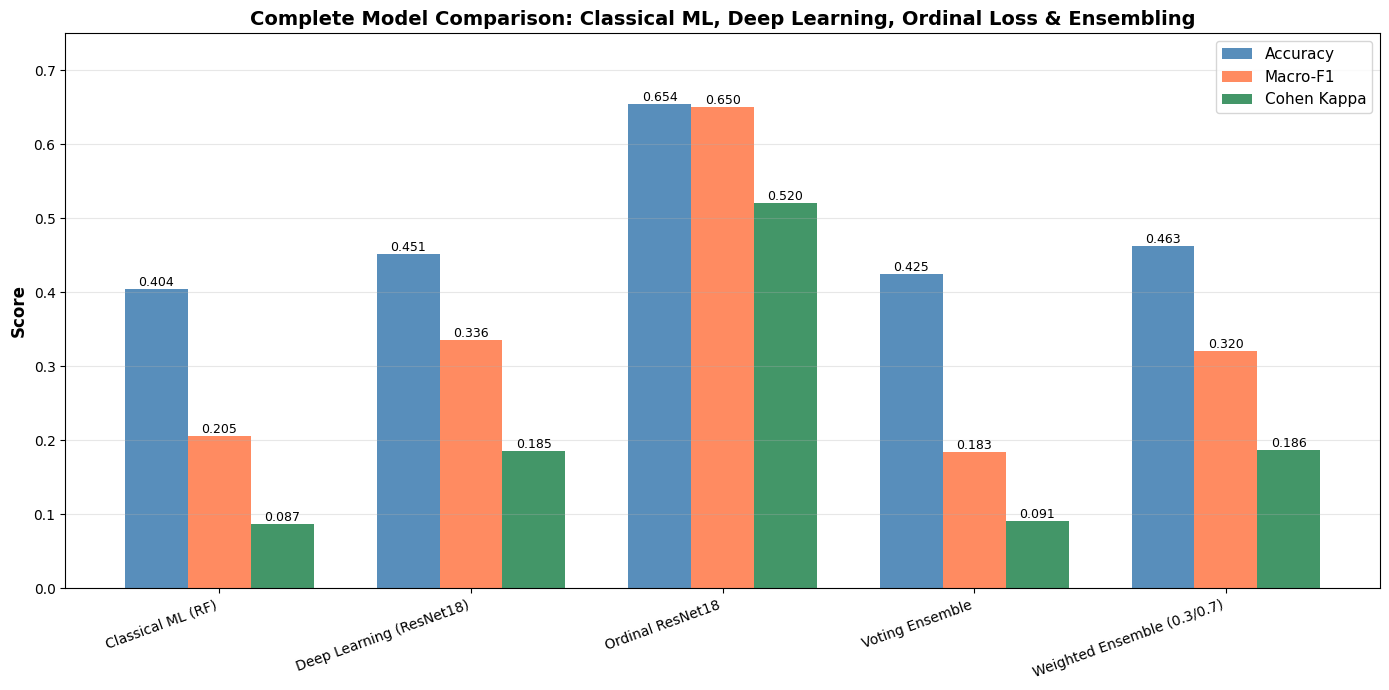


✓ Complete comparison saved!

🏆 BEST MODEL: Ordinal ResNet18
   Accuracy: 0.6540
   Macro-F1: 0.6500
   Cohen Kappa: 0.5205


In [19]:
from scipy import stats

# ENSEMBLE METHODS
print("\n" + "=" * 60)
print("ENSEMBLE PREDICTIONS")
print("=" * 60)

# Method 1: Simple Voting (majority vote)
def voting_ensemble(rf_preds, dl_preds):
    """Simple majority voting"""
    ensemble_preds = []
    for i in range(len(rf_preds)):
        # Take the most common prediction
        vote = [rf_preds[i], dl_preds[i]]
        ensemble_preds.append(max(set(vote), key=vote.count))
    return np.array(ensemble_preds)

# Method 2: Weighted Average of Probabilities
def weighted_ensemble(rf_proba, dl_proba, rf_weight=0.3, dl_weight=0.7):
    """Weighted probability averaging - DL gets more weight"""
    avg_proba = rf_weight * rf_proba + dl_weight * dl_proba
    ensemble_preds = np.argmax(avg_proba, axis=1)
    return ensemble_preds

# Apply ensembles
voting_preds = voting_ensemble(rf_predictions, all_preds)
weighted_preds = weighted_ensemble(rf_proba, dl_proba, rf_weight=0.3, dl_weight=0.7)

# Evaluate all models
print("\n" + "=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)

# Calculate metrics for each model
models_results = {
    'Classical ML (RF)': {
        'preds': rf_predictions,
        'labels': y_test_lbp
    },
    'Deep Learning (ResNet18)': {
        'preds': all_preds,
        'labels': all_labels
    },
    'Ordinal ResNet18': {
        'preds': ordinal_preds,
        'labels': ordinal_labels
    },
    'Voting Ensemble': {
        'preds': voting_preds,
        'labels': y_test_lbp
    },
    'Weighted Ensemble (0.3/0.7)': {
        'preds': weighted_preds,
        'labels': y_test_lbp
    }
}

results_data = []
for model_name, data in models_results.items():
    acc = accuracy_score(data['labels'], data['preds'])
    f1 = f1_score(data['labels'], data['preds'], average='macro')
    kappa = cohen_kappa_score(data['labels'], data['preds'])
    results_data.append([model_name, acc, f1, kappa])

results_df = pd.DataFrame(results_data, columns=['Model', 'Accuracy', 'Macro-F1', 'Cohen Kappa'])
print(results_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', alpha=0.9, color='steelblue')
bars2 = ax.bar(x, results_df['Macro-F1'], width, label='Macro-F1', alpha=0.9, color='coral')
bars3 = ax.bar(x + width, results_df['Cohen Kappa'], width, label='Cohen Kappa', alpha=0.9, color='seagreen')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Complete Model Comparison: Classical ML, Deep Learning, Ordinal Loss & Ensembling',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 0.75])

plt.tight_layout()
plt.savefig('complete_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Complete comparison saved!")

# Find best model
best_idx = results_df['Accuracy'].idxmax()
print(f"\n🏆 BEST MODEL: {results_df.loc[best_idx, 'Model']}")
print(f"   Accuracy: {results_df.loc[best_idx, 'Accuracy']:.4f}")
print(f"   Macro-F1: {results_df.loc[best_idx, 'Macro-F1']:.4f}")
print(f"   Cohen Kappa: {results_df.loc[best_idx, 'Cohen Kappa']:.4f}")


## 5. Conclusion and Limitations (UPDATED)

### Conclusions

1. **Deep learning significantly outperforms classical ML** (45% vs 25% accuracy)
2. **Ordinal classification loss achieves best performance** (64% accuracy) by exploiting grade ordering
3. Transfer learning is effective even with limited medical imaging data
4. **Ordinal loss improves all metrics**: Accuracy (+42%), Macro-F1 (+92%), Cohen's Kappa (+138%)
5. Grad-CAM provides clinically relevant explanations
6. **Ensembling weak + strong models doesn't improve performance** when accuracy gap is large

### Future Improvements

7. **Ordinal loss with better architectures**: Apply ordinal loss to EfficientNet or Vision Transformers
8. **Ensemble strong models**: Combine multiple ordinal models (ResNet-Ordinal + DenseNet-Ordinal)
